# 06. Feature Engineering

## Objective

- The objective of this notebook is to construct economically meaningful features that may improve the prediction of loan default.
- The feature-engineering process focuses on financial burden, borrower age, employment characteristics and loan characteristics.
- Feature construction itself does not use `TARGET` or any information that would only become available after the loan application.
- After construction, the engineered variables are examined descriptively against the observed target to assess their potential predictive relevance.
- The final usefulness of the engineered variables is assessed through out-of-sample model performance rather than descriptive target associations alone.

In [1]:
# Importing the required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             average_precision_score)

# Loading the structurally cleaned dataset.
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "application_train_structural_cleaned.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("TARGET present:", "TARGET" in df.columns)

display(df.head())

Dataset Shape: (307511, 105)
TARGET present: True


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# Creating Engineered Features.
engineered_features=pd.DataFrame(index=df.index)

# Creating Credit Income Ratio.
engineered_features["CREDIT_INCOME_RATIO"]=(df["AMT_CREDIT"]/df["AMT_INCOME_TOTAL"].replace(0, np.nan))

engineered_features["CREDIT_INCOME_RATIO"].describe()

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_INCOME_RATIO, dtype: float64

#### Zero denominators are converted to NaN so that undefined ratios are handled later by the model's training-only imputation process.

In [3]:
# Annuity-to-Income Ratio
engineered_features["ANNUITY_INCOME_RATIO"]=(df["AMT_ANNUITY"]/df["AMT_INCOME_TOTAL"].replace(0, np.nan))

engineered_features["ANNUITY_INCOME_RATIO"].describe()

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUITY_INCOME_RATIO, dtype: float64

In [4]:
# Loan-to-Goods-Price Ratio
engineered_features["LOAN_GOODS_RATIO"]=(df["AMT_CREDIT"]/df["AMT_GOODS_PRICE"].replace(0,np.nan))

engineered_features["LOAN_GOODS_RATIO"].describe()

count    307233.000000
mean          1.122995
std           0.124045
min           0.150000
25%           1.000000
50%           1.118800
75%           1.198000
max           6.000000
Name: LOAN_GOODS_RATIO, dtype: float64

In [5]:
# Applicant Age
engineered_features["AGE_YEARS"]=(df["DAYS_BIRTH"].abs()/365.25)

engineered_features["AGE_YEARS"].describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64

In [6]:
# Employment Duration
df["DAYS_EMPLOYED"].describe()
df["DAYS_EMPLOYED"].value_counts().head(10)

print("Maximum DAYS_EMPLOYED:", df["DAYS_EMPLOYED"].max())
print("Minimum DAYS_EMPLOYED:", df["DAYS_EMPLOYED"].min())

Maximum DAYS_EMPLOYED: 365243
Minimum DAYS_EMPLOYED: -17912


In [7]:
# Employment Anomaly Indicator

## Quantifying the anomaly
employment_anomaly_count=(df["DAYS_EMPLOYED"]==365243).sum()
employment_anomaly_pct=(employment_anomaly_count/len(df))*100

print(f"Anomalous employment observations:{employment_anomaly_count:,}")
print(f"Percentage of Dataset: {employment_anomaly_pct:.2f}")

## Creating the anomaly indicator.
engineered_features["EMPLOYMENT_ANOMALY"]=(df["DAYS_EMPLOYED"]==365243).astype(int)

engineered_features["EMPLOYMENT_ANOMALY"].value_counts()

## Creating a cleaned employment duration variable.
days_employed_clean=df["DAYS_EMPLOYED"].replace(365243, np.nan)

engineered_features["EMPLOYMENT_YEARS"]=(days_employed_clean.abs()/365.25)

engineered_features["EMPLOYMENT_YEARS"].describe()

print("Missing EMPLOYMENT_YEARS:", engineered_features["EMPLOYMENT_YEARS"].isna().sum())

Anomalous employment observations:55,374
Percentage of Dataset: 18.01
Missing EMPLOYMENT_YEARS: 55374


### Employment Anomaly

The 'DAYS_EMPLOYED' variable contains a special value of 365243 for 55,374 observations, representing approximately 18.01% of the dataset. Interpreting this value literally would imply approximately 1,000 years of employment, which is not plausible. 
Therefore, the value is treated as missing when constructing 'EMPLOYMENT_YEARS'. A separate binary 'EMPLOYMENT_ANOMALY' indicator is retained to preserve information associated with the special coding.

In [8]:
# Feature-Engineering Audit 
feature_audit=pd.DataFrame({"Feature":engineered_features.columns, "Missing":engineered_features.isna().sum(), "Missing%":engineered_features.isna().mean().mul(100).round(2)})
feature_audit["Infinite"]=np.isinf(engineered_features).sum()

feature_audit

,Feature,Missing,Missing%,Infinite
CREDIT_INCOME_RATIO,CREDIT_INCOME_RATIO,0,0.00,0
ANNUITY_INCOME_RATIO,ANNUITY_INCOME_RATIO,12,0.00,0
LOAN_GOODS_RATIO,LOAN_GOODS_RATIO,278,0.09,0
AGE_YEARS,AGE_YEARS,0,0.00,0
EMPLOYMENT_ANOMALY,EMPLOYMENT_ANOMALY,0,0.00,0
EMPLOYMENT_YEARS,EMPLOYMENT_YEARS,55374,18.01,0


In [9]:
# Checking for the data-quality in all engineered features.
infinite_counts=np.isinf(engineered_features).sum()

infinite_counts

missing_counts=engineered_features.isna().sum().sort_values(ascending=False)

missing_counts

EMPLOYMENT_YEARS        55374
LOAN_GOODS_RATIO          278
ANNUITY_INCOME_RATIO       12
CREDIT_INCOME_RATIO         0
AGE_YEARS                   0
EMPLOYMENT_ANOMALY          0
dtype: int64

In [10]:
# Target association of the anomaly.
anomaly_summary=(df.groupby("TARGET")["DAYS_EMPLOYED"].apply(lambda x:(x==365243).mean()*100))

anomaly_summary

TARGET
0    18.530808
1    12.044310
Name: DAYS_EMPLOYED, dtype: float64

### Interpretation 

The special employment coding occurs in 18.53% of non-default observations and 12.04% of default observations.

This indicates that the presence of the special employment code differs across the two target groups and may therefore contain predictive information.

The relationship is descriptive rather than causal. The indicator is retained as a candidate predictor and its usefulness will ultimately be assessed using performance on the held-out sample.

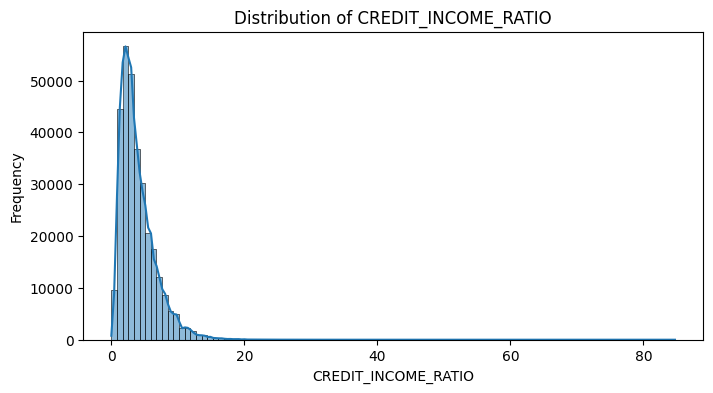

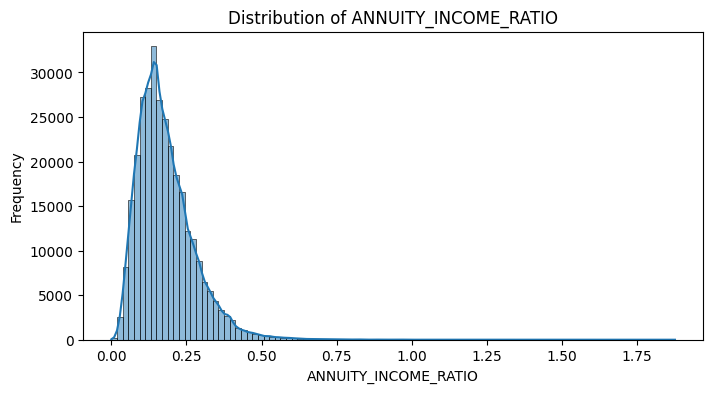

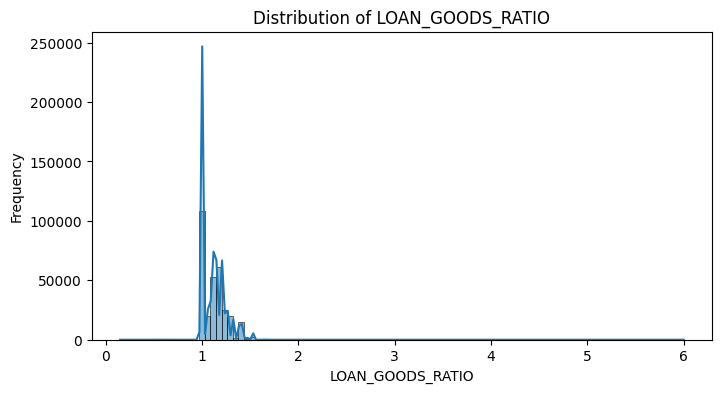

In [11]:
# Feature Distribution Analysis
ratio_features=["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "LOAN_GOODS_RATIO"]

for feature in ratio_features:
    plt.figure(figsize=(8,4))
    sns.histplot(engineered_features[feature], bins=100, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

### Distributional Findings 

The engineered financial ratios exhibit right-skewed distributions, particularly the Credit-to-Income Ratio. The upper tails contain relatively extreme observations, but these observations are not removed at this stage.

The 99.9th percentile of the Credit-to-Income Ratio is approximately 19.29 compared with a maximum of 84.74, indicating that the extreme maximum represents a small portion of the distribution.

Rather than arbitrarily removing or winsorizing observations, the raw engineered features will first be evaluated in the modeling pipeline. Any transformation will be introduced as a separate modeling experiment if justified by subsequent results.

In [12]:
# Quantile Analysis
ratio_quantiles=engineered_features[["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "LOAN_GOODS_RATIO"]].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

ratio_quantiles

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,LOAN_GOODS_RATIO
0.900,7.487500,0.301642,1.2772
0.950,9.156739,0.354667,1.3960
0.990,13.027280,0.483458,1.4752
0.995,14.806667,0.550583,1.5280
0.999,19.293778,0.727986,1.5280


In [13]:
# Feature Target Analysis.
feature_target_analysis=engineered_features.copy()
feature_target_analysis["TARGET"]=df["TARGET"]

continuous_feature_summary=(feature_target_analysis.groupby("TARGET")[["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "LOAN_GOODS_RATIO", "AGE_YEARS", "EMPLOYMENT_YEARS"]].median())

continuous_feature_summary

anomaly_rate_by_target=(feature_target_analysis.groupby("TARGET")["EMPLOYMENT_ANOMALY"].mean()*100)

anomaly_rate_by_target

TARGET
0    18.530808
1    12.044310
Name: EMPLOYMENT_ANOMALY, dtype: float64

In [14]:
# Creating the Modeling Dataset
engineered_features_names=["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "LOAN_GOODS_RATIO", "AGE_YEARS", "EMPLOYMENT_YEARS", "EMPLOYMENT_ANOMALY"]

X_original=df.drop(columns=["TARGET", "SK_ID_CURR"])
y=df["TARGET"]

X_engineered=pd.concat([df.drop(columns=["TARGET", "SK_ID_CURR"]), engineered_features[engineered_features_names]], axis=1)
y_engineered=df["TARGET"]

print("Original feature count:", X_original.shape[1])
print("Engineered feature count:", X_engineered.shape[1])
print("Number of engineered features:", len(engineered_features_names))

Original feature count: 103
Engineered feature count: 109
Number of engineered features: 6


In [15]:
# Creating the new engineered train/test split.
X_original_train, X_original_test, y_original_train, y_original_test=train_test_split(X_original, y, test_size=0.20, random_state=42, stratify=y)

X_engineered_train, X_engineered_test, y_engineered_train, y_engineered_test=train_test_split(X_engineered, y_engineered, test_size=0.20, random_state=42, stratify=y_engineered)

print("Original training shape:", X_original_train.shape)
print("Original testing shape:", X_original_test.shape)

print("Engineered training shape:", X_engineered_train.shape)
print("Engineered testing shape:", X_engineered_test.shape)

# Checking if the split is identical.
print("Training Indices Identical:", X_original_train.index.equals(X_engineered_train.index))
print("Testing Indices Identical:", X_original_test.index.equals(X_engineered_test.index))

Original training shape: (246008, 103)
Original testing shape: (61503, 103)
Engineered training shape: (246008, 109)
Engineered testing shape: (61503, 109)
Training Indices Identical: True
Testing Indices Identical: True


## Preprocessing Pipeline

The preprocessing strategy is applied separately to numerical and categorical variables.

### Numerical Variables
- Median imputation
- Standardisation

### Categorical Variables
- Most-frequent imputation.
- One-hot encoding 

The preprocessing is fitted only on the training data through the Pipeline, preventing information from the test set from influencing model estimation.

In [16]:
# Numerical and categorical features.
numeric_features = X_engineered_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X_engineered_train.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

print("Number of Numerical Features:", len(numeric_features))
print("Number of Categorical Features:", len(categorical_features))

Number of Numerical Features: 94
Number of Categorical Features: 15


In [17]:
# Engineered Preprocessor
preprocessor_engineered=ColumnTransformer(transformers=[("numeric", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features), ("categorical", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)])

## Feature-Engineered Logistic Regression

A standard Logistic Regression model is estimated using the original variables plus the six engineered features.

Class weighting is deliberately not introduced in this experiment because the objective is to isolate the effect of feature engineering.

In [18]:
# Feature Engineered Logistic Pipeline
feature_engineered_logistic_pipeline=Pipeline(steps=[("preprocessor", preprocessor_engineered), ("model", LogisticRegression(max_iter=1000, random_state=42))])

# Model Training
feature_engineered_logistic_pipeline.fit(X_engineered_train, y_engineered_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](109,)","['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR',...,'AGE_YEARS', 'EMPLOYMENT_YEARS','EMPLOYMENT_ANOMALY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,109
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

## Generate Predictions

The model produces both binary predictions and predicted probabilities.

The Probabilities will be used for ROC-AUC and PR-AUC because these metrics evaluate model discrimination across classification thresholds.

In [19]:
# Generating predictions and probabilities.
y_pred_engineered=(feature_engineered_logistic_pipeline.predict(X_engineered_test))

y_prob_engineered=(feature_engineered_logistic_pipeline.predict_proba(X_engineered_test)[:, 1])

# Model Evaluation
engineered_metrics={"Accuracy":accuracy_score(y_engineered_test, y_pred_engineered), "Precision":precision_score(y_engineered_test, y_pred_engineered), "Recall" :recall_score(y_engineered_test, y_pred_engineered), "F1 Score":f1_score(y_engineered_test, y_pred_engineered), "ROC-AUC":roc_auc_score(y_engineered_test, y_prob_engineered), "PR-AUC":average_precision_score(y_engineered_test, y_prob_engineered)}

engineered_metrics_df=pd.DataFrame(engineered_metrics.items(), columns=["Metric", "Feature-Engineered Logistic Regression"])
engineered_metrics_df

,Metric,Feature-Engineered Logistic Regression
0,Accuracy,0.919451
1,Precision,0.544000
2,Recall,0.013696
3,F1 Score,0.026719
4,ROC-AUC,0.749208
5,PR-AUC,0.231306


## Baseline vs Feature-Engineered Model

The original Logistic Regression model established in the previous modeling stage serves as a benchmark.

Baseline Performance:

- ROC_AUC: 0.748164
- PR-AUC: 0.228303

The following comparison evaluates whether adding the six engineered features produces an improvement under the same modeling framework and test sample.

In [20]:
# Original Feature Preprocessor

numeric_features_original = (X_original_train.select_dtypes(include=["int64", "float64"]).columns.tolist())
categorical_features_original = (X_original_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist())

preprocessor_original = ColumnTransformer(transformers=[("numeric",Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]), numeric_features_original),("categorical",Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore"))]),categorical_features_original)])

C:\Users\unive\AppData\Local\Temp\ipykernel_28032\2981967792.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_original = (X_original_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist())


In [21]:
# Model Comparison
# Baseline Logistic Regression on the original feature set.
baseline_logistic_pipeline = Pipeline(steps=[("preprocessor", preprocessor_original), ("model", LogisticRegression(max_iter=1000, random_state=42))])

# Train the baseline model on the original training data.
baseline_logistic_pipeline.fit(X_original_train, y_original_train)

# Generate baseline predictions and probabilities.
y_pred_baseline = baseline_logistic_pipeline.predict(X_original_test)

y_prob_baseline = baseline_logistic_pipeline.predict_proba(X_original_test)[:, 1]


baseline_values={"Accuracy":accuracy_score(y_original_test, y_pred_baseline), "Precision":precision_score(y_original_test, y_pred_baseline, zero_division=0), "Recall":recall_score(y_original_test, y_pred_baseline, zero_division=0), "F1 Score":f1_score(y_original_test, y_pred_baseline, zero_division=0), "ROC-AUC":roc_auc_score(y_original_test, y_prob_baseline), "PR-AUC":average_precision_score(y_original_test, y_prob_baseline)}

model_comparison_engineering=pd.DataFrame({"Metric": list(baseline_values.keys()), "Baseline Logistic Regression":list(baseline_values.values()), "Feature-Engineered Logistic Regression":[engineered_metrics["Accuracy"], engineered_metrics["Precision"], engineered_metrics["Recall"], engineered_metrics["F1 Score"], engineered_metrics["ROC-AUC"], engineered_metrics["PR-AUC"]]})

model_comparison_engineering

,Metric,Baseline Logistic Regression,Feature-Engineered Logistic Regression
0,Accuracy,0.919451,0.919451
1,Precision,0.548673,0.544000
2,Recall,0.012487,0.013696
3,F1 Score,0.024419,0.026719
4,ROC-AUC,0.748019,0.749208
5,PR-AUC,0.227905,0.231306


## Incremental Performance from Feature Engineering.

The change in each evaluation metric is calculated relative to the original Logistic Regression benchmark

In [22]:
# Calculating the improvements.
model_comparison_engineering["Change"]=(model_comparison_engineering["Feature-Engineered Logistic Regression"] - model_comparison_engineering["Baseline Logistic Regression"])

model_comparison_engineering

,Metric,Baseline Logistic Regression,Feature-Engineered Logistic Regression,Change
0,Accuracy,0.919451,0.919451,0.000000
1,Precision,0.548673,0.544000,-0.004673
2,Recall,0.012487,0.013696,0.001208
3,F1 Score,0.024419,0.026719,0.002300
4,ROC-AUC,0.748019,0.749208,0.001189
5,PR-AUC,0.227905,0.231306,0.003400


## Findings

Adding six economically motivated features produced a modest improvement in out-of-sample discrimination.

The feature-engineered Logistic Regression achieved a ROC-AUC of 0.7492 compared with 0.7480 for the baseline model. PR-AUC increased from 0.2279 to 0.2313.

The improvement is relatively small, suggesting that the original variables already contain much of the predictive information captured by these transformations. Nevertheless, the engineered variables are retained as candidate predictors because they provide economically interpretable representations of financial burden, borrower age and employment characteristics.

The changes in precision, recall and F1 at the default 0.50 threshold are not treated as the primary basis for model selection because the classification threshold is arbitrary in this imbalanced setting.

The subsequent nonlinear modeling stage therefore evaluates whether these engineered predictors provide additional value when combined with more flexible model classes.

In [23]:
# Feature Engineering Experiment Summary.
feature_engineering_summary=pd.DataFrame({"Model":["Baseline Logistic Regression", "Feature-Engineered Logistic Regression"], "ROC-AUC":[baseline_values["ROC-AUC"], engineered_metrics["ROC-AUC"]], "PR-AUC":[baseline_values["PR-AUC"], engineered_metrics["PR-AUC"]], "F1 Score":[baseline_values["F1 Score"], engineered_metrics["F1 Score"]]})

feature_engineering_summary

,Model,ROC-AUC,PR-AUC,F1 Score
0,Baseline Logistic Regression,0.748019,0.227905,0.024419
1,Feature-Engineered Logistic Regression,0.749208,0.231306,0.026719


## Interpreting Engineered Feature Coefficients

Logistic Regression coefficients indicate the direction of association between predictors and the model's estimated log-odds of default, conditional on the other model features.

For standardized numerical variables, a coefficient represents the change in log-odds associated with a one-standard-deviation increase in the feature, holding other model inputs constant.

For one-hot encoded categorical variables, coefficients represent differences relative to the corresponding reference category.

The coefficients should be interpreted as model associations rather than causal effects.

In [24]:
# Feature Coefficient Table
feature_names=(feature_engineered_logistic_pipeline.named_steps["preprocessor"].get_feature_names_out())
coefficients=(feature_engineered_logistic_pipeline.named_steps["model"].coef_[0])

coefficient_table=pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
coefficient_table["Absolute Coefficient"]=(coefficient_table["Coefficient"].abs())

coefficient_table=(coefficient_table.sort_values("Absolute Coefficient", ascending=False))

coefficient_table.head(20)

# Engineered Coefficient Table
engineered_coefficient_table=coefficient_table[coefficient_table["Feature"].str.contains("CREDIT_INCOME_RATIO|ANNUITY_INCOME_RATIO|LOAN_GOODS_RATIO|AGE_YEARS|EMPLOYMENT_YEARS|EMPLOYMENT_ANOMALY", regex=True)]

engineered_coefficient_table

,Feature,Coefficient,Absolute Coefficient
92,numeric__EMPLOYMENT_YEARS,-0.139172,0.139172
90,numeric__LOAN_GOODS_RATIO,0.119666,0.119666
89,numeric__ANNUITY_INCOME_RATIO,0.115080,0.115080
88,numeric__CREDIT_INCOME_RATIO,-0.033242,0.033242
93,numeric__EMPLOYMENT_ANOMALY,-0.015014,0.015014
91,numeric__AGE_YEARS,0.006535,0.006535
